# WEEK10 : Lab 9

Question 1)Dataset contains Monthly and Daily prices of Natural gas, starting from January 1997 to current
year. Prices are in nominal dollars. The task is to predict the price of natural gas using LSTM model
for the dataset

https://datahub.io/core/natural-gas#resource-daily or

https://www.kaggle.com/datasets/joebeachcapital/natural-gas-prices

Given the price of last ten 10 days, corresponds to sequence_length, the LSTM model must predict
the price for the 11th day.

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch import nn

In [8]:
df = pd.read_csv("../week9/data/daily.csv").dropna()
y = df['Price'].values
x = np.arange(1, len(y), 1)
minm, maxm = y.min(), y.max()
y = (y - minm) / (maxm - minm)
seq_len = 10
X, Y = [], []
for i in range(5900):
    X.append(y[i:i + seq_len])
    Y.append(y[i + seq_len])
X, Y = np.array(X), np.array(Y)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.1, shuffle=False)

In [9]:
class NGTimeSeries(Dataset):
    def __init__(self, x, y):
        self.x, self.y, self.len = torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32), x.shape[0]
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]
    def __len__(self):
        return self.len

train_loader = DataLoader(NGTimeSeries(x_train, y_train), shuffle=True, batch_size=256)

class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=5, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(in_features=5, out_features=1)
    def forward(self, x):
        return self.fc1(torch.relu(self.lstm(x)[0][:, -1, :]))

0 th iteration :  tensor(0.0187, device='cuda:0', grad_fn=<MseLossBackward0>)
50 th iteration :  tensor(0.0079, device='cuda:0', grad_fn=<MseLossBackward0>)
100 th iteration :  tensor(0.0016, device='cuda:0', grad_fn=<MseLossBackward0>)
150 th iteration :  tensor(0.0016, device='cuda:0', grad_fn=<MseLossBackward0>)
200 th iteration :  tensor(0.0007, device='cuda:0', grad_fn=<MseLossBackward0>)
250 th iteration :  tensor(0.0004, device='cuda:0', grad_fn=<MseLossBackward0>)
300 th iteration :  tensor(0.0026, device='cuda:0', grad_fn=<MseLossBackward0>)
350 th iteration :  tensor(0.0006, device='cuda:0', grad_fn=<MseLossBackward0>)
400 th iteration :  tensor(0.0003, device='cuda:0', grad_fn=<MseLossBackward0>)
450 th iteration :  tensor(0.0002, device='cuda:0', grad_fn=<MseLossBackward0>)
500 th iteration :  tensor(0.0004, device='cuda:0', grad_fn=<MseLossBackward0>)
550 th iteration :  tensor(0.0009, device='cuda:0', grad_fn=<MseLossBackward0>)
600 th iteration :  tensor(0.0004, device='

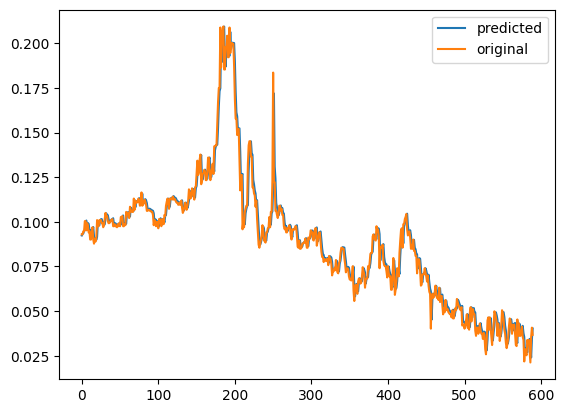

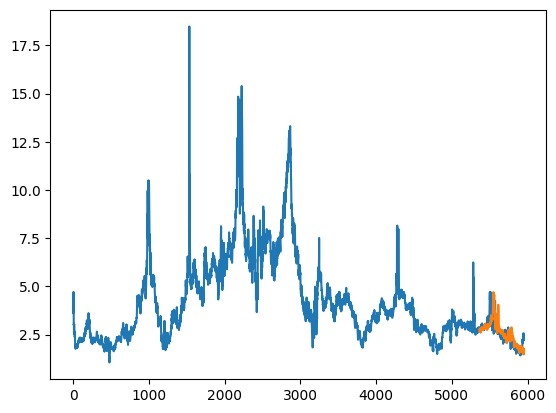

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
epochs = 1500

for i in range(epochs):
    for x_batch, y_batch in train_loader:
        y_pred = model(x_batch.to(device).view(-1, seq_len, 1)).reshape(-1)
        loss = criterion(y_pred, y_batch.to(device))
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    if i % 50 == 0:
        print(i, "th iteration : ", loss)
    
    
#test set actual vs predicted
test_loader = DataLoader(NGTimeSeries(x_test, y_test), batch_size=len(x_test))
test_x, test_y = next(iter(test_loader))
test_pred = model(test_x.to(device).view(-1, 10, 1)).view(-1).cpu().detach().numpy()
test_y = test_y.cpu().detach().numpy()
plt.plot(test_pred, label='predicted')
plt.plot(test_y, label='original')
plt.legend()
plt.show()

y = y * (maxm - minm) + minm
y_pred = test_pred * (maxm - minm) + minm
plt.plot(y)
plt.plot(range(len(y) - len(y_pred), len(y)), y_pred)
plt.show()

Question 2) The data provided at the link https://download.pytorch.org/tutorial/data.zip consists of
names stored in the format {language: [names ...]} i.e. each language contains a list of
names. 

Train a LSTM on a few thousand surnames from 18 languages of origin, and
predict which language a name is from based on the spelling

In [2]:
import os
import torch
import string
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = '../week9/data/names'
device = torch.device('cpu')  
all_chars = string.ascii_lowercase + " "
char_to_idx = {c: i for i, c in enumerate(all_chars)}
n_chars = len(all_chars)
pad_idx = char_to_idx[' ']

# Simplified accent removal
accents_map = str.maketrans(
    'àáäãâåèéêëìíîïòóöôõùúüûñç',
    'aaaaaaeeeeiiiiooooouuuunc'
)
def remove_accents(name):
    return name.lower().translate(accents_map).strip().replace(' ', '_')

# Fixed tensor conversion
def name_to_tensor(name):
    cleaned = remove_accents(name)
    return torch.tensor([char_to_idx.get(c, pad_idx) for c in cleaned], 
                       dtype=torch.long)

class NameDataset(Dataset):
    def __init__(self):
        self.data = []
        self.languages = sorted([f for f in os.listdir(data_dir) if f.endswith('.txt')])
        for lang in self.languages:
            with open(os.path.join(data_dir, lang), 'r', encoding='utf-8') as f:
                self.data += [(name, lang) for name in f.read().splitlines()]
#         random.shuffle(self.data)

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        name, lang = self.data[idx]
        return name_to_tensor(name), self.languages.index(lang)

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, out_dim):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.fc = nn.Linear(hid_dim, out_dim)
    
    def forward(self, x):
        x = self.embed(x)
        _, (hidden, _) = self.lstm(x) 
        return self.fc(hidden[-1])   

loader = DataLoader(NameDataset(), batch_size=64, shuffle=True, collate_fn=lambda b: (
    torch.nn.utils.rnn.pad_sequence([x for x, _ in b], batch_first=True, padding_value=pad_idx),
    torch.tensor([y for _, y in b])
))

model = LSTMClassifier(n_chars, 64, 128, len(dataset.languages)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model.train()
for epoch in range(100):
    for inputs, targets in loader:
        inputs,targets=inputs.to(device),targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

Epoch 10, Loss: 0.4653
Epoch 20, Loss: 0.1436
Epoch 30, Loss: 0.0082
Epoch 40, Loss: 0.1377
Epoch 50, Loss: 0.1303
Epoch 60, Loss: 0.2289
Epoch 70, Loss: 0.0610
Epoch 80, Loss: 0.1774
Epoch 90, Loss: 0.1131
Epoch 100, Loss: 0.1462


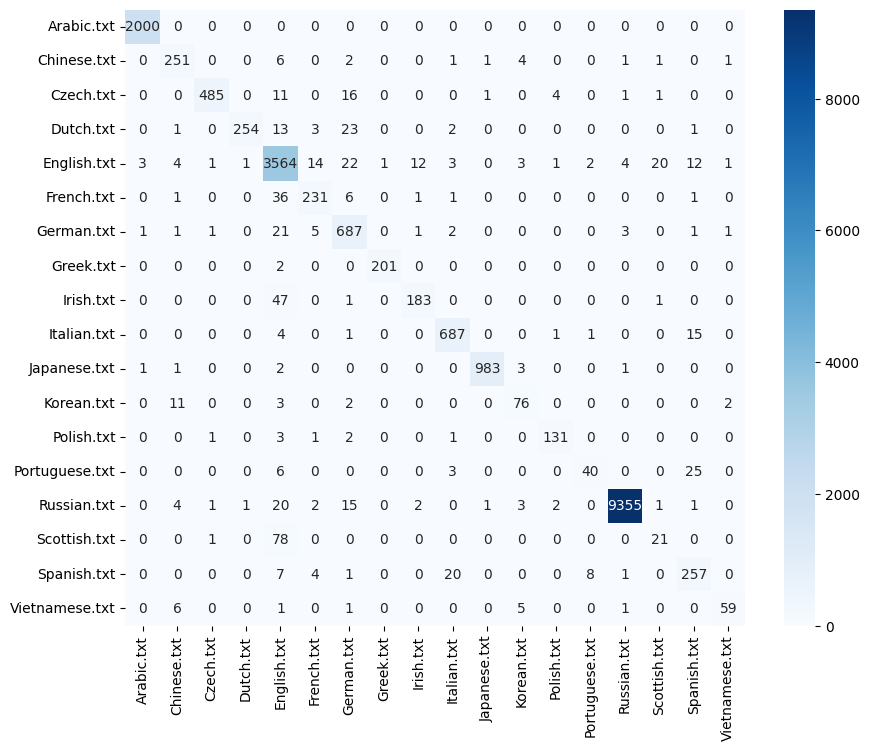

Italian.txt


In [6]:
with torch.no_grad():
    all_preds, all_labels = [], []
    for inputs, targets in loader:
        outputs = model(inputs.to(device))
        all_preds.extend(outputs.argmax(1).cpu())
        all_labels.extend(targets.cpu())

plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(all_labels, all_preds), 
            annot=True, fmt='d',cmap='Blues', xticklabels=dataset.languages, yticklabels=dataset.languages)
plt.show()

def predict(name):
    tensor = name_to_tensor(name).unsqueeze(0).to(device)
    return dataset.languages[model(tensor).argmax().item()]

print(predict("garcia"))  


Question 3)Implement a next character predictor using LSTM Model

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

class Config:
    text = "hello world, this is a character-level RNN example. Let's try to generate more meaningful text. We can try to make it generate sentences. This is a good test." # Increased text variety
    seq_length = 20 
    batch_size = 64 
    embedding_dim = 128 
    hidden_size = 256 
    num_layers = 2
    dropout = 0.3 
    learning_rate = 0.001
    num_epochs = 800 
    temperature = 0.6 
    clip_grad = 5 

chars = sorted(list(set(Config.text)))
char_to_idx = {c:i for i, c in enumerate(chars)}
idx_to_char = {i:c for i, c in enumerate(chars)}
vocab_size = len(chars)

encoded = [char_to_idx[c] for c in Config.text]

class CharDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length
        
    def __len__(self):
        return len(self.data) - self.seq_length
    
    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx:idx+self.seq_length], dtype=torch.long)
        y = torch.tensor(self.data[idx+self.seq_length], dtype=torch.long)
        return x, y

dataset = CharDataset(encoded, Config.seq_length)
dataloader = DataLoader(dataset, batch_size=Config.batch_size, shuffle=True)

class CharLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, Config.embedding_dim)
        self.lstm = nn.LSTM(Config.embedding_dim, Config.hidden_size,
                                    num_layers=Config.num_layers, 
                                    dropout=Config.dropout,
                                    batch_first=True)
        self.fc = nn.Linear(Config.hidden_size, vocab_size)
        
    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out[:, -1, :])
        return out, hidden

model = CharLSTM()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=Config.learning_rate)

for epoch in range(Config.num_epochs):
    model.train()
    total_loss = 0
    
    for inputs, targets in dataloader:
        optimizer.zero_grad()
        outputs, _ = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), Config.clip_grad) # Gradient clipping
        optimizer.step()
        
        total_loss += loss.item()
    
    if (epoch+1) % 50 == 0:
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1}/{Config.num_epochs} | Loss: {avg_loss:.4f}")

def generate_text(model, seed, length=200): #Increased length
    model.eval()
    device = next(model.parameters()).device
    generated = list(seed)
    
    h = (torch.zeros(Config.num_layers, 1, Config.hidden_size).to(device),
         torch.zeros(Config.num_layers, 1, Config.hidden_size).to(device))
    
    for _ in range(length):
        input_seq = generated[-Config.seq_length:]
        x = torch.tensor([char_to_idx[c] for c in input_seq], 
                          dtype=torch.long).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output, h = model(x, h)
            
        probs = F.softmax(output / Config.temperature, dim=1).cpu()
        next_char = torch.multinomial(probs, num_samples=1).item()
        
        generated.append(idx_to_char[next_char])
    
    return ''.join(generated)

seed = "hello world, "
generated = generate_text(model, seed, length=200)
print(f"\nGenerated text:\n{generated}")

Epoch 50/800 | Loss: 0.2805
Epoch 100/800 | Loss: 0.0341
Epoch 150/800 | Loss: 0.0148
Epoch 200/800 | Loss: 0.0077
Epoch 250/800 | Loss: 0.0044
Epoch 300/800 | Loss: 0.0032
Epoch 350/800 | Loss: 0.0026
Epoch 400/800 | Loss: 0.0021
Epoch 450/800 | Loss: 0.0016
Epoch 500/800 | Loss: 0.0013
Epoch 550/800 | Loss: 0.0010
Epoch 600/800 | Loss: 0.0009
Epoch 650/800 | Loss: 0.0007
Epoch 700/800 | Loss: 0.0007
Epoch 750/800 | Loss: 0.0006
Epoch 800/800 | Loss: 0.0005

Generated text:
hello world, exat. We can try to make it generate sentences. This is a gore test. We can its is to generate more manngful text. We can try to make it generate sentences. This is a goerate meaningful text. We can t


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

data = torch.arange(1, 21, dtype=torch.float32)

seq_length = 5
batch_size = 4
input_size = 1

inputs = data.view(batch_size, seq_length, input_size)

hidden_size = 1
num_layers = 1
lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

for name, param in lstm.named_parameters():
    nn.init.constant_(param, 1.0)

h0 = torch.zeros(num_layers, batch_size, hidden_size)
c0 = torch.zeros(num_layers, batch_size, hidden_size)

output, (hn, cn) = lstm(inputs, (h0, c0))

print("Input:")
print(inputs.squeeze(-1))
print("\nLSTM Output (last hidden state for each timestep):")
print(output.squeeze(-1))
print("\nFinal Hidden State hn:")
print(hn.squeeze())
print("\nFinal Cell State cn:")
print(cn.squeeze())
"""Input:
tensor([[ 1.,  2.,  3.,  4.,  5.],
        [ 6.,  7.,  8.,  9., 10.],
        [11., 12., 13., 14., 15.],
        [16., 17., 18., 19., 20.]])

LSTM Output (last hidden state for each timestep):
tensor([[0.7038, 0.9501, 0.9916, 0.9983, 0.9996],
        [0.7612, 0.9639, 0.9950, 0.9993, 0.9999],
        [0.7616, 0.9640, 0.9951, 0.9993, 0.9999],
        [0.7616, 0.9640, 0.9951, 0.9993, 0.9999]], grad_fn=<SqueezeBackward1>)

Final Hidden State hn:
tensor([0.9996, 0.9999, 0.9999, 0.9999], grad_fn=<SqueezeBackward0>)

Final Cell State cn:
tensor([4.9173, 4.9995, 5.0000, 5.0000], grad_fn=<SqueezeBackward0>)

"""

Input:
tensor([[ 1.,  2.,  3.,  4.,  5.],
        [ 6.,  7.,  8.,  9., 10.],
        [11., 12., 13., 14., 15.],
        [16., 17., 18., 19., 20.]])

LSTM Output (last hidden state for each timestep):
tensor([[0.7038, 0.9501, 0.9916, 0.9983, 0.9996],
        [0.7612, 0.9639, 0.9950, 0.9993, 0.9999],
        [0.7616, 0.9640, 0.9951, 0.9993, 0.9999],
        [0.7616, 0.9640, 0.9951, 0.9993, 0.9999]], grad_fn=<SqueezeBackward1>)

Final Hidden State hn:
tensor([0.9996, 0.9999, 0.9999, 0.9999], grad_fn=<SqueezeBackward0>)

Final Cell State cn:
tensor([4.9173, 4.9995, 5.0000, 5.0000], grad_fn=<SqueezeBackward0>)


'Input:\ntensor([[ 1.,  2.,  3.,  4.,  5.],\n        [ 6.,  7.,  8.,  9., 10.],\n        [11., 12., 13., 14., 15.],\n        [16., 17., 18., 19., 20.]])\n\nLSTM Output (last hidden state for each timestep):\ntensor([[0.7038, 0.9501, 0.9916, 0.9983, 0.9996],\n        [0.7612, 0.9639, 0.9950, 0.9993, 0.9999],\n        [0.7616, 0.9640, 0.9951, 0.9993, 0.9999],\n        [0.7616, 0.9640, 0.9951, 0.9993, 0.9999]], grad_fn=<SqueezeBackward1>)\n\nFinal Hidden State hn:\ntensor([0.9996, 0.9999, 0.9999, 0.9999], grad_fn=<SqueezeBackward0>)\n\nFinal Cell State cn:\ntensor([4.9173, 4.9995, 5.0000, 5.0000], grad_fn=<SqueezeBackward0>)\n\n'